# Numerical Methods for Solving Ordinary Differential Equations (ODEs)

## Introduction - Non-linear Differential Equations

In the chapter on [diffential equations](Differential_Equations.ipynb), we explored linear ordinary differential equations (ODEs). While linear ODEs can often be solved analytically, using e.g., `sympy.dsolve`, non-linear ODEs typically require numerical methods for their solutions. This chapter focuses on time integration methods specifically designed to handle non-linear differential equations.

### The differential equation

Differential equations model a change of some quantity and are typically expressed along with what is initially known, as so called *initial values (IV)*.  Thus, the *initial value problem (IVP)* we will consider is of the form:

$$
(\mathrm{IVP}) \begin{cases}y^{\prime}(x)=f(x, y) & (\mathrm{ODE}) \\ y\left(x_0\right)=y_0 & (\mathrm{IV})\end{cases}
$$ {#eq-ivp}


or as a system:

$$
(\mathrm{IVP})\left\{\begin{array}{rlr}
y^{\prime}(x) & =f(x, y, v), & y\left(x_0\right)=y_0 \\
v^{\prime}(x) & =f(x, y, v), & v\left(x_0\right)=v_0 \\
& \vdots
\end{array}\right. 
$$ {#eq-ivp-system}

These are solved in parallel with the methods described below for solving (1a).

::: {#exm-simple-ode}

In [1]:
#| echo: false
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
import mechanicskit as mk

%config InlineBackend.figure_format = 'svg'

plt.rcParams.update({
    "font.family": "serif",      # Use serif fonts for text
    "mathtext.fontset": "cm",    # 'cm' stands for Computer Modern (Standard LaTeX font)
})

import warnings
warnings.filterwarnings('ignore', message='divide by zero encountered')

In [2]:
#| code-fold: true
x = sp.symbols('x', real=True)
y = sp.Function('y')(x)


In [3]:
#| code-fold: false
DE = sp.Eq(y.diff(x, 1), y)
IV = {y.subs(x, 0): 1}
sp.dsolve(DE, ics=IV)

Eq(y(x), exp(x))

:::

In this chapter, we study various numerical methods for solving the initial value problem (@eq-ivp). Our goal is to find approximate values of the solution $y(x)$ at discrete points $x_0, x_1, x_2, \ldots$ without needing an analytical formula.

To build intuition, we start with a concrete example before developing the general theory.

### A First Numerical Approximation {#sec-first-numerical-approximation}

Consider the differential equation
$$
\frac{d y}{d x} = y, \quad y(0) = 1
$$

We know from @exm-simple-ode that the exact solution is $y(x) = e^x$. But suppose we did not know this. How could we approximate the solution numerically?

The idea is simple: use the definition of the derivative. Since $\frac{dy}{dx} \approx \frac{y(x + h) - y(x)}{h}$ for small step size $h$, we can rearrange to get

$$
y(x+h) \approx y(x)+\frac{dy}{dx}h
$$

Since the differential equation tells us that $\frac{dy}{dx}=y$, we can write an update scheme:

$$
y_{i+1} = y_i + y_i h 
$$ {#eq-euler-update}

Starting from the initial condition $y_0 = 1$ at $x_0 = 0$, we step forward with $h=0.1$:

In [4]:
#| code-fold: false
h = 0.1 # step size
x_vals = np.arange(0, 1 + h, h) # x values from 0 to 1
y_0 = 1 # initial condition y(0) = 1
y_vals = [y_0] # list to store y values
for i, x_i in enumerate(x_vals[:-1]): # exclude last x value
    y_new = y_vals[-1] + h * y_vals[-1] # Update scheme
    y_vals.append(y_new) # Append new y value to the list
    x_new = x_vals[i + 1]  # The x value where y_new is computed
    print(f"Step {i+1}: x = {x_i:.1f}, y = {y_vals[-2]:.6f} -> x = {x_new:.1f}, y_new = {y_new:.6f}")


Step 1: x = 0.0, y = 1.000000 -> x = 0.1, y_new = 1.100000
Step 2: x = 0.1, y = 1.100000 -> x = 0.2, y_new = 1.210000
Step 3: x = 0.2, y = 1.210000 -> x = 0.3, y_new = 1.331000
Step 4: x = 0.3, y = 1.331000 -> x = 0.4, y_new = 1.464100
Step 5: x = 0.4, y = 1.464100 -> x = 0.5, y_new = 1.610510
Step 6: x = 0.5, y = 1.610510 -> x = 0.6, y_new = 1.771561
Step 7: x = 0.6, y = 1.771561 -> x = 0.7, y_new = 1.948717
Step 8: x = 0.7, y = 1.948717 -> x = 0.8, y_new = 2.143589
Step 9: x = 0.8, y = 2.143589 -> x = 0.9, y_new = 2.357948
Step 10: x = 0.9, y = 2.357948 -> x = 1.0, y_new = 2.593742


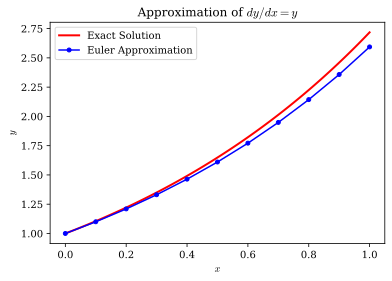

In [5]:
#| code-fold: true
#| classes: size-80
fig, ax = plt.subplots(figsize=(6, 4))

y_exact = sp.dsolve(DE, ics=IV).rhs
mk.fplot(y_exact, (x, 0, 1),
         label='Exact Solution',
         color='red',lw=2)

ax.plot(x_vals, y_vals, 'o-b', 
        label='Euler Approximation',
        markersize=4)
ax.set(xlabel='$x$', ylabel='$y$', title="Approximation of $dy/dx = y$")
ax.legend()
plt.show()

The numerical approximation tracks the exact solution reasonably well, though we observe a growing error. This raises several important questions:

- Will this method always produce a solution?
- Is the solution we compute the *correct* one?
- How does the error depend on the step size $h$?
- When can we trust numerical methods to work?

To answer these questions, we need some mathematical theory.

::: {#thm-CauchyContinuity}

If $f(x, y)$ is continuous, then a solution to $y^{\prime}(x)=f(x, y)$ exists. ([Augustin Louis Cauchy](https://en.wikipedia.org/wiki/Augustin-Louis_Cauchy), [Giuseppe Peano](https://en.wikipedia.org/wiki/Giuseppe_Peano))

:::

Continuity guarantees existence, but it does not guarantee uniqueness. Multiple solution curves might pass through the same initial point, making the problem ill-posed for numerical methods.

::: {#thm-LipschitzContinuity}

Let $f(x, y)$ be continuous for all points $(x, y): a \leq x \leq b,-\infty \leq y \leq \infty$, where $a, b$ are finite. If $f$ satisfies a [Lipschitz condition](https://en.wikipedia.org/wiki/Lipschitz_continuity) ([Rudolf Lipschitz](https://en.wikipedia.org/wiki/Rudolf_Lipschitz))

$$
\left|f(x, y_1)-f\left(x, y_2\right)\right| \leq L\left|y_1-y_2\right|
$${#eq-lipschitz-condition}

for $a \leq x \leq b$ and all $y_1, y_2$, then there exists a *unique* solution to (@eq-ivp) for every initial value $y\left(x_0\right)=y_0, x_0 \in[a, b]$. The constant $L$ is called the Lipschitz constant.

:::

### Understanding the Lipschitz Condition

The inequality (@eq-lipschitz-condition) compares what happens when we evaluate $f$ at two different $y$ values while keeping $x$ fixed. The subscripts 1 and 2 simply mean "two different values we're comparing."

The Lipschitz condition says: pick any two different values $y_1$ and $y_2$. When we plug them into $f(x, y_1)$ and $f(x, y_2)$ (at the same $x$), the difference in outputs cannot be more than $L$ times the difference in inputs.


This means the function $f$ cannot change too abruptly when we vary $y$ while keeping $x$ fixed. The constant $L$ bounds how sensitive $f$ is to changes in $y$. The smaller $L$, the more "well-behaved" the function.


:::{#exm-Lipschitz1} 
For our introductory example $y' = y$, we have $f(x,y) = y$. Let's check the Lipschitz condition. Pick any two values, say $y_1 = 3$ and $y_2 = 5$:

$$
|f(x,3) - f(x,5)| = |3 - 5| = 2 = 1 \cdot |3-5|
$$

The difference between outputs is $|3-5| = 2$, which equals exactly 1 times the difference between inputs, also 2. Try any other pair and you'll always get the same factor of 1. This shows that for $f(x,y) = y$, the Lipschitz constant is $L = 1$.

More generally, for any $y_1$ and $y_2$:
$$
|f(x,y_1) - f(x,y_2)| = |y_1 - y_2| = 1 \cdot |y_1 - y_2|
$$

This tells us the problem is well-posed: the solution exists and is unique.
:::


**Why this matters for engineering**: Consider a mechanical system whose state evolves according to a differential equation. If small changes in the current state lead to wildly different future behavior (large $L$ or no Lipschitz bound at all), the system is sensitive to measurement errors and numerical approximations. Conversely, when the Lipschitz constant is finite and moderate, small errors in our numerical approximation stay controlled as we step forward in time.

The Lipschitz condition also guarantees uniqueness of solutions. This is essential: if multiple solution curves could pass through our initial condition, which one should a numerical method follow? Uniqueness removes this ambiguity.

### Computing the Lipschitz Constant in Practice

For most engineering problems, we can find the Lipschitz constant using calculus. If the partial derivative $\frac{\partial f}{\partial y}$ exists and is bounded in our domain of interest, then its maximum value serves as a Lipschitz constant. This follows directly from the [mean value theorem](https://en.wikipedia.org/wiki/Mean_value_theorem).

Let's see this with a different example:

::: {#exm-lipschitz-xy}

Consider the differential equation

$$
y^{\prime}(x)= x y
$$

with initial condition $y(0)=1$ on the interval $x \in[0,1]$. Here, $f(x, y) = xy$. We compute the partial derivative

$$
\frac{\partial f}{\partial y} = x
$$

On the interval $[0,1]$, this derivative varies between 0 and 1, so its maximum is 1. We can verify this directly: for any two values $y_1$ and $y_2$,

$$
\left|xy_1 - xy_2\right|=|x|\left|y_1-y_2\right| \leq 1 \cdot \left|y_1-y_2\right|
$$

since $|x| \leq 1$ on our domain. Thus, the Lipschitz constant is $L=1$.

:::

For systems of differential equations expressed in matrix form, we can compute the Lipschitz constant using matrix norms.

::: {#thm-LipschitzConstant}

For the linear system $\mathbf{y}^{\prime}=\mathbf{A} \mathbf{y}$ where $\mathbf{A}$ is a constant matrix, the Lipschitz constant equals the matrix norm

$$L=\|\mathbf{A}\|_{\infty}=\max _i \sum_j\left|a_{i j}\right|$$

This is the maximum absolute row sum: add the absolute values of entries in each row, then take the maximum across all rows. This norm is easy to compute.

:::

### Why Lipschitz Continuity Matters for Numerical Methods

We now connect these theoretical results to the practical task of computing numerical solutions. The Lipschitz constant $L$ controls how errors behave as we step through our numerical approximation. When we take a step of size $h$, any error we introduce gets multiplied by approximately $1 + Lh$ as we move forward. Over many steps, errors can accumulate, but the Lipschitz constant bounds this accumulation.

Returning to our introductory example with $y' = y$, we found $L = 1$. With step size $h = 0.1$, errors grow by a factor of roughly $1 + 1 \cdot 0.1 = 1.1$ per step. Over 10 steps from $x=0$ to $x=1$, the cumulative error factor is approximately $(1.1)^{10} \approx 2.59$. This explains why we see visible deviation from the exact solution in the figure above, even though the method tracks the general trend correctly.

This has immediate practical consequences. If $L$ is small, we can take larger steps $h$ without errors growing uncontrollably. If $L$ is large, we must use smaller steps to maintain accuracy. Advanced numerical methods use estimates of $L$ to automatically adjust the step size, taking large steps when the solution is smooth and small steps when it changes rapidly.

The Lipschitz condition also enables convergence proofs. We can show that as the step size $h \to 0$, numerical methods like the one used in @sec-first-numerical-approximation converge to the true solution. The convergence rate depends on both the method's order and the Lipschitz constant. This is why Lipschitz continuity appears throughout the theory of numerical differential equations: it provides the mathematical foundation for trusting that our numerical approximations actually approach the correct answer.

## Euler's Method

Having explored the basic idea through our introductory example, we now formalize Euler's method for general initial value problems.

### The General Algorithm

For the general initial value problem
$$
y'(x) = f(x, y), \quad y(x_0) = y_0
$$
Euler's method constructs a sequence of approximations $y_0, y_1, y_2, \ldots$ at points $x_0, x_1, x_2, \ldots$ separated by step size $h$. The update formula is

$$
y_{i+1} = y_i + h f(x_i, y_i) 
$${#eq-euler-general-update}

This generalizes equation (@eq-euler-update) from our introductory example, where $f(x,y) = y$.

### Geometric Interpretation

At the initial point $\left(x_0, y_0\right)$ we obtain a tangent direction $y^{\prime}=f\left(x_0, y_0\right)$ from the differential equation. If we step $h$ in $x$ with this direction, we arrive at the point $\left(x_1, y_1\right)$, where $x_1=x_0+h$ and $y_1=y_0+h f\left(x_0, y_0\right)$. We then approximate $y_1 \approx y\left(x_1\right)$. 

We determine a new tangent direction $y^{\prime}=f\left(x_1, y_1\right)$ at this new point, continue the step $h$ in $x$ with this updated direction to reach $\left(x_2, y_2\right)$, where $x_2=x_1+h=x_0+2h$ and $y_2=y_1+h f\left(x_1, y_1\right)$. We hope that $y_2 \approx y\left(x_2\right)$, and so on.


In [6]:
#| code-fold: true
from matplotlib.animation import FuncAnimation

# Recompute the Euler approximation for animation
h = 0.1
x_vals = np.arange(0, 1 + h, h)
y_vals = [1.0]  # Initial condition

for i in range(len(x_vals) - 1):
    y_new = y_vals[-1] + h * y_vals[-1]
    y_vals.append(y_new)

# Exact solution
x_exact = np.linspace(0, 1, 100)
y_exact_vals = np.exp(x_exact)

# Create animation
fig, ax = plt.subplots(figsize=(8, 5), dpi=150)

def animate(frame):
    ax.clear()
    
    # IVP info box at top center
    ivp_text = (
        r"$\frac{dy}{dx} = y, \quad y(0) = 1$"
    )
    ax.text(0.5, 0.98, ivp_text, 
            transform=ax.transAxes,
            fontsize=11,
            verticalalignment='top',
            horizontalalignment='center',
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
    
    # Plot exact solution
    ax.plot(x_exact, y_exact_vals, 'r-', lw=2, label='Exact Solution')
    
    # Plot Euler approximation up to current frame
    if frame > 0:
        ax.plot(x_vals[:frame+1], y_vals[:frame+1], 'o-b', 
                lw=2, markersize=4, label='Euler Approximation')
    else:
        ax.plot(x_vals[0], y_vals[0], 'ob', markersize=4, label='Euler Approximation')
    
    # Show tangent direction for current step
    if frame < len(x_vals) - 1:
        x_curr = x_vals[frame]
        y_curr = y_vals[frame]
        
        # Tangent line segment: from current point with slope f(x,y) = y
        slope = y_curr  # Since dy/dx = y
        x_tangent = [x_curr, x_curr + h]
        y_tangent = [y_curr, y_curr + h * slope]
        
        ax.plot(x_tangent, y_tangent, 'g--', lw=1.5, alpha=0.7, label='Tangent Direction')
        ax.plot(x_curr, y_curr, 'go', markersize=6)  # Current point
        
        # Next point
        ax.plot(x_vals[frame+1], y_vals[frame+1], 'gs', markersize=6)
        
        # Info text box in lower right
        y_next = y_vals[frame+1]
        f_val = y_curr  # f(x,y) = y
        
        info_text = (
            f"$f(x,y) = y$\n"
            f"$y_{{{frame+1}}} = y_{{{frame}}} + h f(x_{{{frame}}}, y_{{{frame}}})$\n"
            f"${y_next:.4f} = {y_curr:.4f} + {h:.1f} \\cdot {f_val:.4f}$"
        )
        
        ax.text(0.98, 0.02, info_text, 
                transform=ax.transAxes,
                fontsize=10,
                verticalalignment='bottom',
                horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$')
    ax.set_title(f"Euler's Method: Step {frame}/{len(x_vals)-1}")
    ax.legend(loc='upper left')
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(0, 3)
    ax.grid(True, alpha=0.3)

anim = FuncAnimation(fig, animate, frames=len(x_vals), interval=800, repeat=True)
plt.close()

mk.to_responsive_html(anim, container_id='euler-animation')


The method is based on the Taylor expansion, truncated after the first derivative. At point $x_i$ we replace $y^{\prime}\left(x_i\right)$ with a *forward difference*, whereby the differential equation transforms into

$$
\frac{y\left(x_{i+1}\right)-y\left(x_i\right)}{h} \approx y^{\prime}\left(x_i\right)=f\left(x_i, y_i\right)
$$

Rearranging gives equation (@eq-euler-general-update). The method follows the tangent line at each step, which explains why errors accumulate: we repeatedly approximate a curve by straight line segments.

## Euler's Method for Systems of ODEs

Consider the pendulum example from the chapter on [differential equations](Differential_Equations.ipynb). The second-order ODE
$$
\frac{d^{2} \theta}{d t^{2}}+\frac{g}{L} \sin \theta=0
$$  
can be rewritten as a system of first-order ODEs by introducing the angular velocity $\omega = \frac{d\theta}{dt}$:
$$
\begin{cases}
\frac{d \omega}{d t} = -\frac{g}{L} \sin \theta \\
\frac{d \theta}{d t} = \omega 
\end{cases}
$$  

We tackle the solution by approximating both $\theta$ and $\omega$ at discrete time steps using Euler's method, starting from the highest derivative, i.e., $\omega$ and working our way down to $\theta$.


$$
\begin{cases}
\frac{d \omega}{d t}  \approx \frac{\omega_{i+1}-\omega_i}{h} =   -\frac{g}{L} \sin \theta_i  \\
\frac{d \theta}{d t}  \approx \frac{\theta_{i+1}-\theta_i}{h} =  \omega_i 
\end{cases}
$$ {#eq-pendulum-approx-Euler}


Leading to the update formulas:
$$\begin{cases}
\omega_{i+1} = \omega_i - h \frac{g}{L} \sin \theta_i  \\
\theta_{i+1} = \theta_i + h \omega_i 
\end{cases}$$

### Euler-Cromer Method

:::{.callout-important}
We have two choices in (@eq-pendulum-approx-Euler): use the current value $\omega_i$ to update $\theta$, or use the newly computed value $\omega_{i+1}$. The latter approach leads to a different numerical method called the *semi-implicit Euler method* or *Euler-Cromer method*, which has better stability properties for certain problems. 

$$
\begin{cases}
\frac{d \omega}{d t}  \approx \frac{\omega_{i+1}-\omega_i}{h} =   -\frac{g}{L} \sin \theta_i  \\
\frac{d \theta}{d t}  \approx \frac{\theta_{i+1}-\theta_i}{h} =  \omega_{i+1} 
\end{cases}
$$

leading to the (stable) Euler-Cromer update formulas:
$$
\begin{cases}
\omega_{i+1} = \omega_i - h \frac{g}{L} \sin \theta_i  \\
\theta_{i+1} = \theta_i + h \omega_{i+1} 
\end{cases}
$$

:::

See [this video](https://www.youtube.com/watch?v=nCg3aXn5F3M) for a demonstration of the difference between Euler and Euler-Cromer methods for orbital simulation. The video gives a great introduction to the importance of numerical stability in simulations and introduces the concept of phase-space convervation.

### Pendulum Example - Non-linear ODE

In [7]:
#| code-fold: true
from matplotlib.animation import FuncAnimation

# Pendulum parameters
g = 9.81  # gravitational acceleration (m/s^2)
L = 1.0   # length of pendulum (m)

# Initial conditions: start horizontally
theta_0 = np.pi / 2  # 90 degrees
omega_0 = 0.0        # initially at rest

# Time parameters
h = 0.01  # time step (s)
T_approx = 2 * np.pi * np.sqrt(L / g) * 1.2  # Approximate period (with factor for large amplitude)
t_max = T_approx  # Simulate one period
t_vals = np.arange(0, t_max, h)

# Euler-Cromer method
theta_vals = [theta_0]
omega_vals = [omega_0]

for i in range(len(t_vals) - 1):
    omega_new = omega_vals[-1] - h * (g / L) * np.sin(theta_vals[-1])
    theta_new = theta_vals[-1] + h * omega_new  # Use updated omega
    
    omega_vals.append(omega_new)
    theta_vals.append(theta_new)

# Create animation with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), dpi=150)

def animate(frame):
    ax1.clear()
    ax2.clear()
    
    # Left plot: Pendulum visualization in xy coordinates
    theta_curr = theta_vals[frame]
    x = L * np.sin(theta_curr)
    y = -L * np.cos(theta_curr)
    
    # Draw pendulum
    ax1.plot([0, x], [0, y], 'k-', lw=2)  # Rod
    ax1.plot(0, 0, 'ko', markersize=8)    # Pivot point
    ax1.plot(x, y, 'ro', markersize=15)   # Bob
    
    # Reference circle
    circle_theta = np.linspace(0, 2*np.pi, 100)
    circle_x = L * np.sin(circle_theta)
    circle_y = -L * np.cos(circle_theta)
    ax1.plot(circle_x, circle_y, 'b--', lw=0.5, alpha=0.3)
    
    ax1.set_xlim(-1.5*L, 1.5*L)
    ax1.set_ylim(-1.5*L, 0.5*L)
    ax1.set_aspect('equal')
    ax1.set_xlabel('$x$ (m)')
    ax1.set_ylabel('$y$ (m)')
    ax1.set_title(f'Pendulum Motion')
    ax1.grid(True, alpha=0.3)
    
    # Info box for pendulum
    info_text = (
        f"$t = {t_vals[frame]:.2f}$ s\n"
        f"$\\theta = {theta_curr*180/np.pi:.1f}°$\n"
        f"$\\omega = {omega_vals[frame]:.2f}$ rad/s"
    )
    ax1.text(0.02, 0.98, info_text,
             transform=ax1.transAxes,
             fontsize=9,
             verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    # Right plot: Angle vs time
    ax2.plot(t_vals[:frame+1], np.array(theta_vals[:frame+1]) * 180/np.pi, 
             'b-', lw=2)
    ax2.plot(t_vals[frame], theta_vals[frame] * 180/np.pi, 
             'ro', markersize=6)
    
    ax2.set_xlim(0, t_max)
    ax2.set_ylim(-100, 100)
    ax2.set_xlabel('Time $t$ (s)')
    ax2.set_ylabel(r'Angle $\theta$ (degrees)')
    ax2.set_title(r'$\theta$ vs $t$')
    ax2.grid(True, alpha=0.3)
    ax2.axhline(y=0, color='k', linestyle='--', lw=0.5, alpha=0.5)
    
    # IVP info box at top
    ivp_text = (
        r"$\ddot{\theta} + \frac{g}{L}\sin\theta = 0, \quad \theta(0) = 90°, \quad \dot{\theta}(0) = 0$"
    )
    fig.text(0.5, 0.96, ivp_text,
             fontsize=11,
             ha='center',
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

# Create animation with appropriate number of frames (sample every 5th frame for speed)
frame_skip = 5
frames = range(0, len(t_vals), frame_skip)

anim = FuncAnimation(fig, animate, frames=frames, interval=50, repeat=True)
plt.close()

mk.to_responsive_html(anim, container_id='pendulum-animation')